In [1]:
#HyBRIS playground
from HyBRIS_utils import *

#load data

#Ground truth data with sowing and harvest dates
field = pd.read_csv('Example/GroundTruth_example.csv')
field['Date'] = pd.to_datetime(field['Date']) #make sure the date column is in datetime format

#paths to example data files, the Sentinel 1 and 2 time series
s2_path = 'Example/Sentinel2_example.csv'
s1_path = 'Example/Sentinel1_example.csv'

In [2]:
# Open Sentinel-2, remove NA, merge observation on the same day, and add Vegetation indices
bandsused = ['B1', 'B2', 'B3', 'B4','B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
bandsusedS1 = ['VV', 'VH', 'angle']

s2 = openSentinel2file(s2_path, bandsused)
s2 = add_vis(s2)

print("--- Sentinel-2 data ---")
print(s2.head())
print(s2.columns.tolist())
print("length of Sentinel-2 data:", len(s2.index))

--- Sentinel-2 data ---
        date   ID      B1        B2        B3        B4        B5        B6  \
0 2017-02-02  805  0.1810  0.146847  0.127662  0.142548  0.158526  0.186567   
1 2017-03-14  805  0.1520  0.123200  0.112700  0.118062  0.136071  0.160533   
2 2017-06-02  805  0.1521  0.133249  0.141351  0.146690  0.176314  0.283800   
3 2017-08-06  805  0.1277  0.097652  0.094056  0.055867  0.100267  0.396382   
4 2017-09-25  805  0.1531  0.111255  0.105860  0.068047  0.111100  0.371900   

         B7        B8       B8A       B11       B12      NDVI       BSI  \
0  0.213400  0.215361  0.256548  0.227450  0.136186  0.157436  0.795207   
1  0.176150  0.171359  0.191736  0.200977  0.146933  0.129931  0.838407   
2  0.328567  0.302796  0.346075  0.250917  0.186694  0.362601  0.711408   
3  0.507820  0.492038  0.536714  0.141331  0.055357  1.000000  0.042948   
4  0.472700  0.452800  0.507314  0.138050  0.061147  0.920798  0.093158   

       NDTI      NDSI      NDWI       EVI  
0  0.5

In [3]:
#and Sentinel-1 files, remove NA, merge observation on the same day, select most present orbit, and add Vegetation indices
s1 = openSentinel1file(s1_path, bandsusedS1)

#Split ascending and descending orbits
s1_des = s1[s1['orbit'] == 'DESCENDING']  # Select only descending orbits
s1_asc = s1[s1['orbit'] == 'ASCENDING']  # Select only ascending orbits

# Select most present orbit and add radar vegetation index
s1_des = add_vis_radar(selectOrbit(s1_des, selectMostPresent=True))
s1_asc = add_vis_radar(selectOrbit(s1_asc, selectMostPresent=True))

s1 = pd.concat([s1_des, s1_asc])

print("--- Sentinel-1 data ---")
print(s1.head())
print(s1.columns.tolist())
print("length of Sentinel-1 data:", len(s1.index))

--- Sentinel-1 data ---
         date   ID       orbit  orbitNumber       VV       VH    angle  \
0  2017-01-01  805  DESCENDING           37 -11.7947 -18.1706  34.6895   
2  2017-01-07  805  DESCENDING           37 -12.2076 -20.2785  34.5932   
6  2017-01-13  805  DESCENDING           37  -9.1669 -15.4798  34.6905   
8  2017-01-19  805  DESCENDING           37 -12.6063 -22.0931  34.5947   
12 2017-01-25  805  DESCENDING           37 -12.8256 -21.4186  34.6911   

         RVI     VH_VV     VV_VH  
0   0.468284  0.609919  0.390081  
2   0.259389  0.397409  0.602591  
6   0.477134  0.617818  0.382182  
8   0.124762  0.219891  0.780109  
12  0.205814  0.331951  0.668049  
['date', 'ID', 'orbit', 'orbitNumber', 'VV', 'VH', 'angle', 'RVI', 'VH_VV', 'VV_VH']
length of Sentinel-1 data: 801


In [4]:
#specify bands for S1 and S2 fusion
s2_band = "BSI"
s1_band = "VV_VH"

#Fuse S1 and S2 time series based on given bands(similar to daily_index_with_contributions, but specifically for HyBRIS)
hybris = calculate_hybris_vectorized(s1, s2)
print("--- HyBRIS data ---")
print(hybris.head())
print(hybris.columns.tolist())
print("length of HyBRIS data:", len(hybris.index))

--- HyBRIS data ---
        date  daily_index  s1_contribution  s2_contribution  \
0 2017-01-01     0.626824              1.0              0.0   
1 2017-01-02     0.638431              1.0              0.0   
2 2017-01-03     0.657688              1.0              0.0   
3 2017-01-04     0.685002              1.0              0.0   
4 2017-01-05     0.617260              1.0              0.0   

   daily_index_smooth   ID         ID_date  
0            0.557126  805  805_2017-01-01  
1            0.547994  805  805_2017-01-02  
2            0.537387  805  805_2017-01-03  
3            0.526023  805  805_2017-01-04  
4            0.513628  805  805_2017-01-05  
['date', 'daily_index', 's1_contribution', 's2_contribution', 'daily_index_smooth', 'ID', 'ID_date']
length of HyBRIS data: 3053


Filtered data length:
60
25


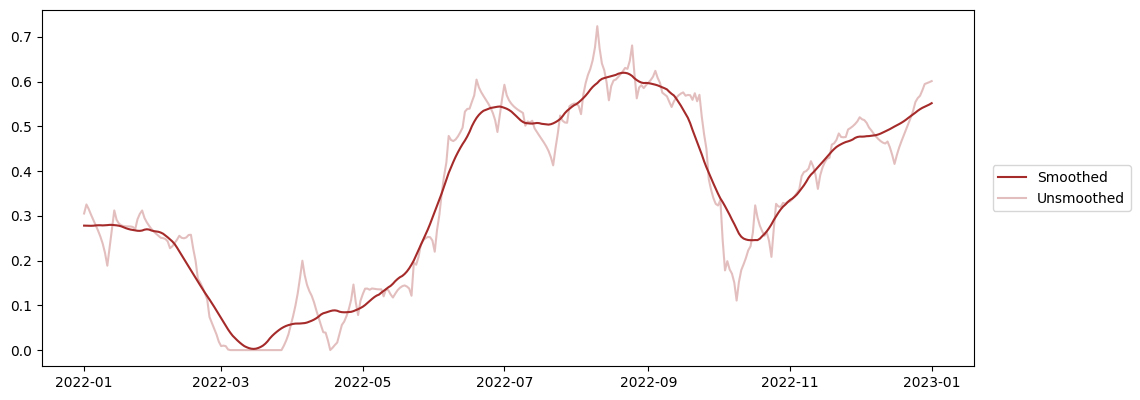

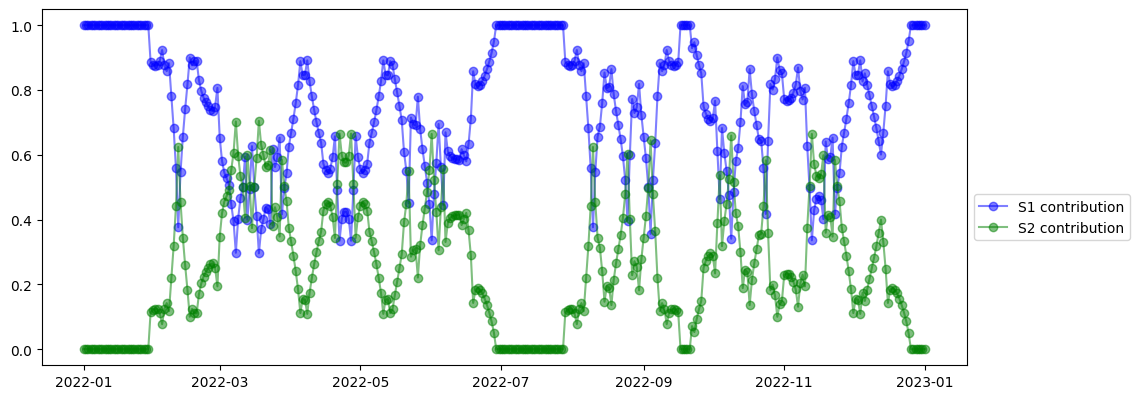

In [6]:
#define start and end date for examples
start_date = pd.to_datetime("2022-01-01")
end_date = pd.to_datetime("2023-01-01")

#Filter all data to the same time period for easier plotting
field_example = filter_by_date(field, start_date=start_date, end_date=end_date, date_column="Date")
s2_example = filter_by_date(s2, start_date=start_date, end_date=end_date)
s1_example = filter_by_date(s1, start_date=start_date, end_date=end_date)
hybris_example = filter_by_date(hybris, start_date=start_date, end_date=end_date)

print("Filtered data length:")
print(len(s1_example))
print(len(s2_example))

####PLOT FIGURE WITH 1 PANELS
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(11.5, 4.1), sharex=True)
plot_hybris(hybris_example,
            add_pred_sow_harv = False,
            plot_tillages=False,
            plot_dormant=False,
            add_groundtruth=False,
            ax = axes, date_col = "date")

plt.tight_layout()
plt.show()

####PLOT FIGURE WITH 2 PANELS
#First panel is the HyBRIS index, smoothed and unsmoothed
#Second panel shows the contrbution of Sentinel-1 or Sentinel-2 per day. Contributions of the two satellites is between [0,1] and sums to 1.
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(11.5, 4.1), sharex=True)
plot_time_series(hybris_example["s1_contribution"], hybris_example['date'], color='blue', title="S1 contribution", show=False, alpha=0.5, marker='o', ax=axes)
plot_time_series(hybris_example["s2_contribution"], hybris_example['date'], color='green', title="S2 contribution", show=False, alpha=0.5, marker='o', ax=axes)

plt.tight_layout()
plt.show()
